# Heart Disease Classification with a Neural Network
### UCI Heart Disease Dataset – Full Pipeline
---
**Goal:** Build an Artificial Neural Network that classifies whether a patient has heart disease (binary: 0 = no disease, 1 = disease present).

The dataset comes from four institutions:
- Cleveland Clinic Foundation  
- Hungarian Institute of Cardiology  
- V.A. Medical Center, Long Beach  
- University Hospital, Zurich (Switzerland)

We start with `processed.cleveland.data` for training/validation, then merge all four processed files for a combined inference evaluation.


# Tasks

Our goal is to create an artificial neural network model capable of classifying if a patient will have a heart disease. We will work through the entire data science lifecycle. At the end of the class, you will submit the final notebook you have from this exercise.

1.Import the necessary libraries

2.Load the Dataset

3.Perform EDA (at least 4 visualizations)

3.Perform Feature Engineering

4.Split the Dataset (train and test sets)

5.Initialize a very simple neural network

6.Train your neural network

7.Make predictions and evaluate the model

8.Drive conclusions

# Utlization

-NumPy

-Pandas

-Matplotlib Seaborn

-Scikit-learn

-PyTorch

-Neural Network (ReLU activations, dropout regularisation, sigmoid output)

-ROC-AUC score, confusion matrix, ROC curve plots.

-Google Colab

-Claude for Mac 4.6

Author: Oscar Martinez / Claude For Mac 4.6

oskytm@hotmail.com

Created:2026-05-20



## 1. Import the Necessary Libraries

In [1]:
# ── Standard & Data ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Preprocessing ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# ── Neural Network (PyTorch) ──────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("All libraries imported successfully.")
print(f"PyTorch version : {torch.__version__}")
print(f"NumPy version   : {np.__version__}")
print(f"Pandas version  : {pd.__version__}")


All libraries imported successfully.
PyTorch version : 2.10.0+cu128
NumPy version   : 2.0.2
Pandas version  : 2.2.2


## 2. Load the Dataset

We load **`processed.cleveland.data`** as the primary dataset.  
Column names follow the 14-attribute subset documented in `heart-disease.names`.

| # | Feature | Description |
|---|---------|-------------|
| 1 | age | Age in years |
| 2 | sex | 1 = male, 0 = female |
| 3 | cp | Chest pain type (1–4) |
| 4 | trestbps | Resting blood pressure (mmHg) |
| 5 | chol | Serum cholesterol (mg/dl) |
| 6 | fbs | Fasting blood sugar > 120 mg/dl (1 = true) |
| 7 | restecg | Resting ECG results (0–2) |
| 8 | thalach | Max heart rate achieved |
| 9 | exang | Exercise-induced angina (1 = yes) |
| 10 | oldpeak | ST depression induced by exercise |
| 11 | slope | Slope of peak exercise ST segment |
| 12 | ca | Number of major vessels coloured by fluoroscopy (0–3) |
| 13 | thal | 3 = normal; 6 = fixed defect; 7 = reversable defect |
| 14 | **target** | Heart disease: 0 = absent, 1–4 = present |


In [4]:
COLUMNS = ['age','sex','cp','trestbps','chol','fbs','restecg',
           'thalach','exang','oldpeak','slope','ca','thal','target']

# ── Unzip the dataset file ──────────────────────────────────────────────
!unzip -o heart_disease_dataset.zip

# ── Primary dataset: Cleveland ────────────────────────────────────────────
cleveland = pd.read_csv('processed.cleveland.data', header=None,
                        names=COLUMNS, na_values='?')

print(f"Cleveland shape : {cleveland.shape}")
cleveland.head(10)

Archive:  heart_disease_dataset.zip
  inflating: Index                   
  inflating: WARNING                 
  inflating: ask-detrano             
  inflating: bak                     
  inflating: cleve.mod               
  inflating: cleveland.data          
   creating: costs/
  inflating: costs/Index             
  inflating: costs/heart-disease.README  
  inflating: costs/heart-disease.cost  
  inflating: costs/heart-disease.delay  
  inflating: costs/heart-disease.expense  
  inflating: costs/heart-disease.group  
  inflating: heart-disease.names     
  inflating: hungarian.data          
  inflating: long-beach-va.data      
  inflating: new.data                
  inflating: processed.cleveland.data  
  inflating: processed.hungarian.data  
  inflating: processed.switzerland.data  
  inflating: processed.va.data       
  inflating: reprocessed.hungarian.data  
  inflating: switzerland.data        
Cleveland shape : (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


In [5]:
# ── Basic info ────────────────────────────────────────────────────────────
print(cleveland.info())
print("\nMissing values per column:")
print(cleveland.isnull().sum())
print("\nTarget value counts:")
print(cleveland['target'].value_counts().sort_index())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
targ

## 3. Exploratory Data Analysis (EDA)

We produce **six visualisations** covering:
1. Target class distribution (binary)  
2. Age distribution by disease presence  
3. Correlation heat-map  
4. Chest-pain type vs disease  
5. Max heart rate vs age coloured by disease  
6. Pairplot of the most predictive features  


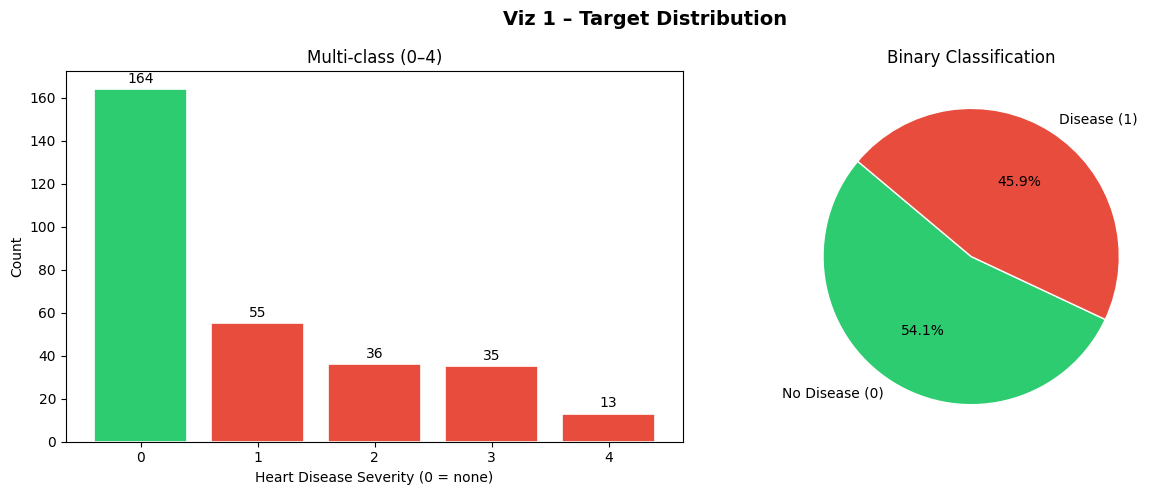

No disease: 164  |  Disease: 139


In [6]:
# ── Binary target (0 = no disease, 1 = disease present) ──────────────────
df = cleveland.copy()
df['target_bin'] = (df['target'] > 0).astype(int)

# ── Viz 1 : Target class distribution ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Viz 1 – Target Distribution', fontsize=14, fontweight='bold')

# Raw (0–4)
raw_counts = df['target'].value_counts().sort_index()
colors_raw = ['#2ecc71' if i == 0 else '#e74c3c' for i in raw_counts.index]
axes[0].bar(raw_counts.index, raw_counts.values, color=colors_raw, edgecolor='white', linewidth=1.2)
axes[0].set_xlabel('Heart Disease Severity (0 = none)')
axes[0].set_ylabel('Count')
axes[0].set_title('Multi-class (0–4)')
for i, (idx, val) in enumerate(zip(raw_counts.index, raw_counts.values)):
    axes[0].text(idx, val + 3, str(val), ha='center', fontsize=10)

# Binary
bin_counts = df['target_bin'].value_counts().sort_index()
labels = ['No Disease (0)', 'Disease (1)']
colors_bin = ['#2ecc71', '#e74c3c']
axes[1].pie(bin_counts.values, labels=labels, colors=colors_bin,
            autopct='%1.1f%%', startangle=140, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Binary Classification')

plt.tight_layout()
plt.savefig('viz1_target_dist.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"No disease: {bin_counts[0]}  |  Disease: {bin_counts[1]}")


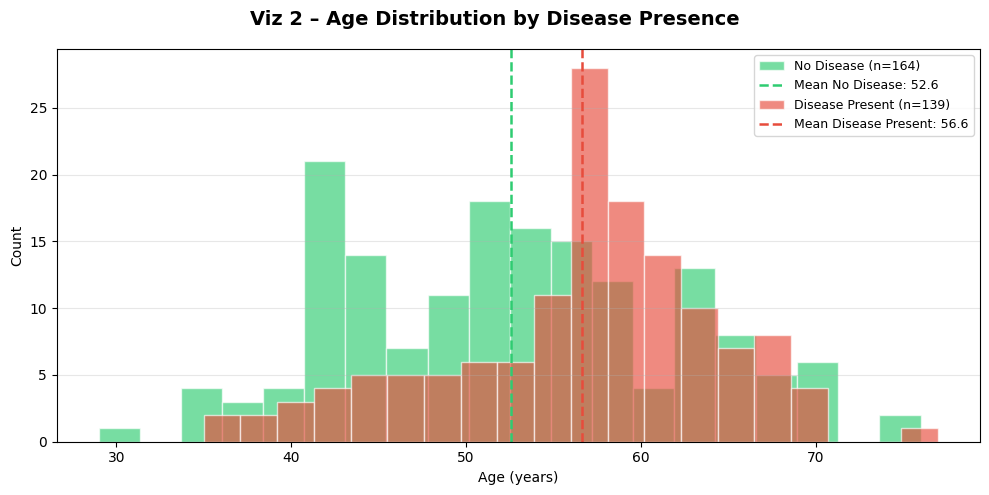

In [7]:
# ── Viz 2 : Age distribution by disease presence ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Viz 2 – Age Distribution by Disease Presence', fontsize=14, fontweight='bold')

for val, label, color in zip([0, 1], ['No Disease', 'Disease Present'], ['#2ecc71', '#e74c3c']):
    subset = df[df['target_bin'] == val]['age']
    ax.hist(subset, bins=20, alpha=0.65, label=f'{label} (n={len(subset)})',
            color=color, edgecolor='white')
    ax.axvline(subset.mean(), color=color, linestyle='--', linewidth=1.8,
               label=f'Mean {label}: {subset.mean():.1f}')

ax.set_xlabel('Age (years)')
ax.set_ylabel('Count')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('viz2_age_dist.png', dpi=120, bbox_inches='tight')
plt.show()


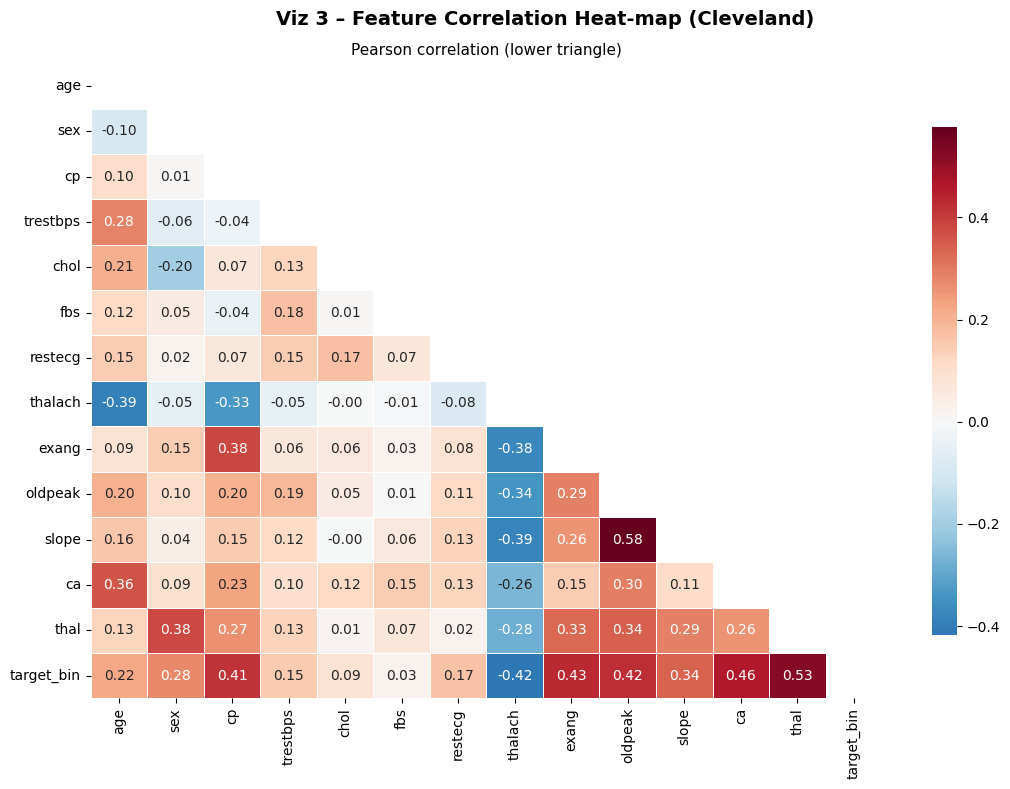

In [8]:
# ── Viz 3 : Correlation heat-map ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))
fig.suptitle('Viz 3 – Feature Correlation Heat-map (Cleveland)', fontsize=14, fontweight='bold')

corr = df.drop(columns='target').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=.5, ax=ax, cbar_kws={'shrink': .8})
ax.set_title('Pearson correlation (lower triangle)', fontsize=11)
plt.tight_layout()
plt.savefig('viz3_correlation.png', dpi=120, bbox_inches='tight')
plt.show()


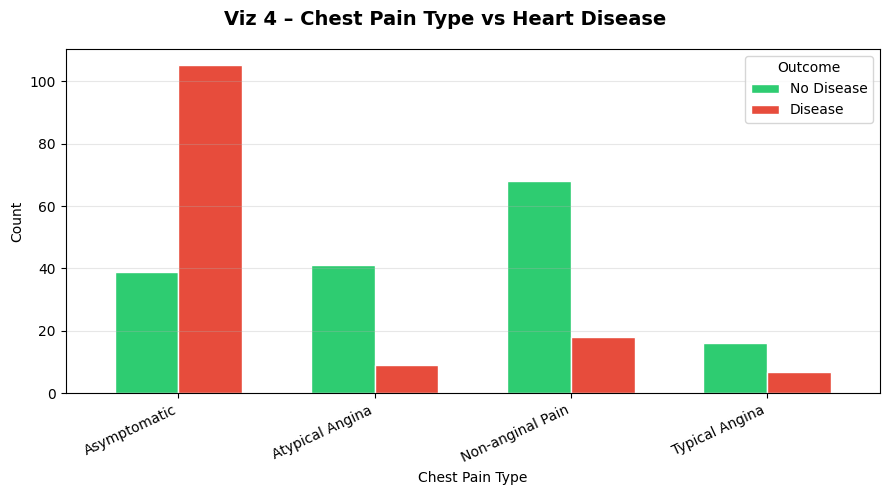

In [9]:
# ── Viz 4 : Chest pain type vs disease ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Viz 4 – Chest Pain Type vs Heart Disease', fontsize=14, fontweight='bold')

cp_map = {1: 'Typical Angina', 2: 'Atypical Angina',
          3: 'Non-anginal Pain', 4: 'Asymptomatic'}
df['cp_label'] = df['cp'].map(cp_map)

cp_disease = (df.groupby(['cp_label', 'target_bin'])
                .size().unstack(fill_value=0))
cp_disease.columns = ['No Disease', 'Disease']
cp_disease.plot(kind='bar', ax=ax, color=['#2ecc71','#e74c3c'],
                edgecolor='white', width=0.65)
ax.set_xlabel('Chest Pain Type')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
ax.legend(title='Outcome')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('viz4_chest_pain.png', dpi=120, bbox_inches='tight')
plt.show()


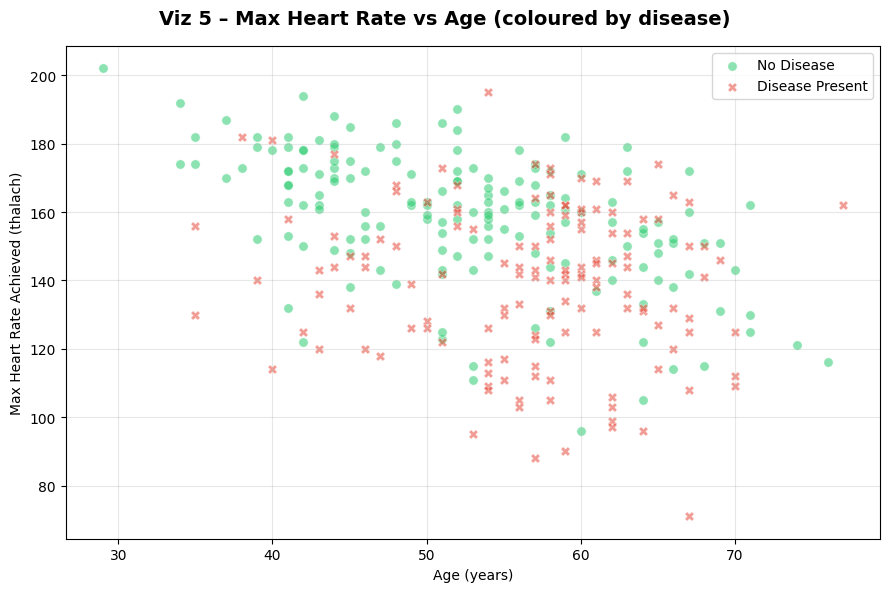

In [10]:
# ── Viz 5 : Max heart rate vs Age (scatter) ──────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
fig.suptitle('Viz 5 – Max Heart Rate vs Age (coloured by disease)', fontsize=14, fontweight='bold')

for val, label, color, marker in zip([0, 1],
                                     ['No Disease', 'Disease Present'],
                                     ['#2ecc71', '#e74c3c'],
                                     ['o', 'X']):
    sub = df[df['target_bin'] == val]
    ax.scatter(sub['age'], sub['thalach'], alpha=0.55, s=45,
               c=color, label=label, marker=marker, edgecolors='white', linewidths=0.5)

ax.set_xlabel('Age (years)')
ax.set_ylabel('Max Heart Rate Achieved (thalach)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('viz5_hr_age.png', dpi=120, bbox_inches='tight')
plt.show()


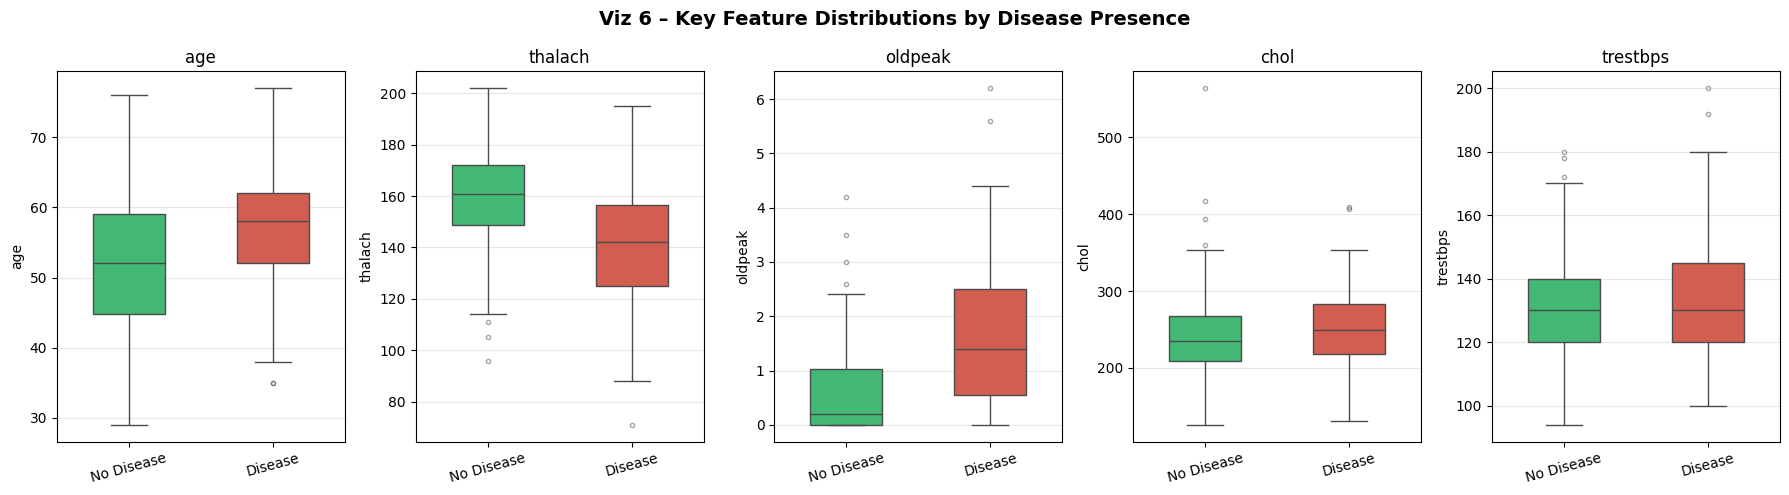

In [12]:
# ── Viz 6 : Boxplots – top features vs target ────────────────────────────
top_features = ['age', 'thalach', 'oldpeak', 'chol', 'trestbps']
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Viz 6 – Key Feature Distributions by Disease Presence', fontsize=14, fontweight='bold')

palette = {'0': '#2ecc71', '1': '#e74c3c'}
for ax, feat in zip(axes, top_features):
    sns.boxplot(data=df, x='target_bin', y=feat, palette=palette, ax=ax,
                width=0.5, flierprops=dict(marker='o', markersize=3, alpha=0.5))
    ax.set_xticklabels(['No Disease', 'Disease'], rotation=15)
    ax.set_xlabel('')
    ax.set_title(feat)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('viz6_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. Feature Engineering

Steps:
1. **Binary target** – collapse classes 1–4 into 1 (disease present)  
2. **Handle missing values** – impute with column median  
3. **Merge all four processed datasets** for a richer combined dataset  
4. **One-hot encode** nominal categorical features (`cp`, `restecg`, `thal`, `slope`)  
5. **Standard scaling** of continuous features (applied after the train/test split to prevent data leakage)


In [13]:
# ── Load all four processed files ─────────────────────────────────────────
files = {
    'cleveland'  : 'processed.cleveland.data',
    'hungarian'  : 'processed.hungarian.data',
    'switzerland': 'processed.switzerland.data',
    'va'         : 'processed.va.data'
}

frames = []
for name, path in files.items():
    tmp = pd.read_csv(path, header=None, names=COLUMNS, na_values='?')
    tmp['source'] = name
    frames.append(tmp)

all_data = pd.concat(frames, ignore_index=True)
print(f"Combined dataset shape: {all_data.shape}")
print("\nMissing values:")
print(all_data.isnull().sum())


Combined dataset shape: (920, 15)

Missing values:
age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalach      55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
target        0
source        0
dtype: int64


In [14]:
# ── Binary target ─────────────────────────────────────────────────────────
all_data['target'] = (all_data['target'] > 0).astype(int)

# ── Impute missing values with column median ──────────────────────────────
numeric_cols = all_data.select_dtypes(include='number').columns.tolist()
for col in numeric_cols:
    if all_data[col].isnull().any():
        all_data[col].fillna(all_data[col].median(), inplace=True)

print("Missing values after imputation:")
print(all_data.isnull().sum())
print(f"\nTarget distribution after binarisation:\n{all_data['target'].value_counts()}")


Missing values after imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
source      0
dtype: int64

Target distribution after binarisation:
target
1    509
0    411
Name: count, dtype: int64


In [15]:
# ── One-hot encode nominal categoricals ──────────────────────────────────
CATEGORICAL = ['cp', 'restecg', 'slope', 'thal']
CONTINUOUS   = ['age','trestbps','chol','fbs','thalach','exang','oldpeak','ca']

df_enc = pd.get_dummies(all_data.drop(columns='source'),
                        columns=CATEGORICAL, drop_first=False)

# Separate features and target
X = df_enc.drop(columns='target').values.astype(np.float32)
y = df_enc['target'].values.astype(np.float32)

print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")
print(f"Feature columns :\n{list(df_enc.drop(columns='target').columns)}")


Feature matrix shape : (920, 22)
Target vector shape  : (920,)
Feature columns :
['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'cp_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_0.0', 'restecg_1.0', 'restecg_2.0', 'slope_1.0', 'slope_2.0', 'slope_3.0', 'thal_3.0', 'thal_6.0', 'thal_7.0']


## 5. Split the Dataset (Train / Test)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# ── Scale AFTER splitting to prevent leakage ──────────────────────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Training set   : {X_train.shape[0]} samples")
print(f"Test set       : {X_test.shape[0]} samples")
print(f"\nClass balance in training set:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {int(u)}: {c}  ({c/len(y_train)*100:.1f}%)")


Training set   : 736 samples
Test set       : 184 samples

Class balance in training set:
  Class 0: 329  (44.7%)
  Class 1: 407  (55.3%)


## 6. Initialize the Neural Network

Architecture: a **feed-forward ANN** with:

| Layer | Size | Activation |
|-------|------|-----------|
| Input | *n_features* | – |
| Hidden 1 | 64 | ReLU + Dropout(0.3) |
| Hidden 2 | 32 | ReLU + Dropout(0.3) |
| Hidden 3 | 16 | ReLU |
| Output | 1 | Sigmoid |

Loss: `BCELoss` (Binary Cross-Entropy)  
Optimiser: `Adam` with learning-rate 0.001


In [17]:
class HeartDiseaseANN(nn.Module):
    """Simple 3-hidden-layer feed-forward network for binary classification."""

    def __init__(self, input_dim: int):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# ── Instantiate ───────────────────────────────────────────────────────────
INPUT_DIM = X_train.shape[1]
model     = HeartDiseaseANN(INPUT_DIM)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")


HeartDiseaseANN(
  (network): Sequential(
    (0): Linear(in_features=22, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=1, bias=True)
    (9): Sigmoid()
  )
)

Total trainable parameters: 4,097


## 7. Train the Neural Network

In [19]:
# ── DataLoaders ───────────────────────────────────────────────────────────
def make_loader(X, y, batch_size=32, shuffle=True):
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
test_loader  = make_loader(X_test,  y_test,  shuffle=False)

# ── Training setup ────────────────────────────────────────────────────────
EPOCHS    = 150
LR        = 0.001
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10,
                                                  factor=0.5)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

def accuracy(preds, targets, threshold=0.5):
    return ((preds >= threshold).float() == targets).float().mean().item()

# ── Training loop ─────────────────────────────────────────────────────────
for epoch in range(1, EPOCHS + 1):
    # -- Train --
    model.train()
    t_loss, t_acc = 0.0, 0.0
    for Xb, yb in train_loader:
        optimizer.zero_grad()
        out  = model(Xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()
        t_acc  += accuracy(out, yb)
    t_loss /= len(train_loader); t_acc /= len(train_loader)

    # -- Validate --
    model.eval()
    v_loss, v_acc = 0.0, 0.0
    with torch.no_grad():
        for Xb, yb in test_loader:
            out  = model(Xb)
            loss = criterion(out, yb)
            v_loss += loss.item()
            v_acc  += accuracy(out, yb)
    v_loss /= len(test_loader); v_acc /= len(test_loader)

    scheduler.step(v_loss)

    history['train_loss'].append(t_loss);  history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc);    history['val_acc'].append(v_acc)

    if epoch % 25 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS}  "
              f"Train Loss: {t_loss:.4f}  Train Acc: {t_acc:.4f}  |  "
              f"Val Loss: {v_loss:.4f}  Val Acc: {v_acc:.4f}")

print("\nTraining complete.")

Epoch   1/150  Train Loss: 0.7008  Train Acc: 0.4579  |  Val Loss: 0.6835  Val Acc: 0.5330
Epoch  25/150  Train Loss: 0.3465  Train Acc: 0.8628  |  Val Loss: 0.3608  Val Acc: 0.8542
Epoch  50/150  Train Loss: 0.2923  Train Acc: 0.8913  |  Val Loss: 0.3722  Val Acc: 0.8715
Epoch  75/150  Train Loss: 0.2831  Train Acc: 0.8845  |  Val Loss: 0.3765  Val Acc: 0.8750
Epoch 100/150  Train Loss: 0.2785  Train Acc: 0.8927  |  Val Loss: 0.3762  Val Acc: 0.8750
Epoch 125/150  Train Loss: 0.2868  Train Acc: 0.8899  |  Val Loss: 0.3766  Val Acc: 0.8750
Epoch 150/150  Train Loss: 0.2690  Train Acc: 0.8981  |  Val Loss: 0.3767  Val Acc: 0.8750

Training complete.


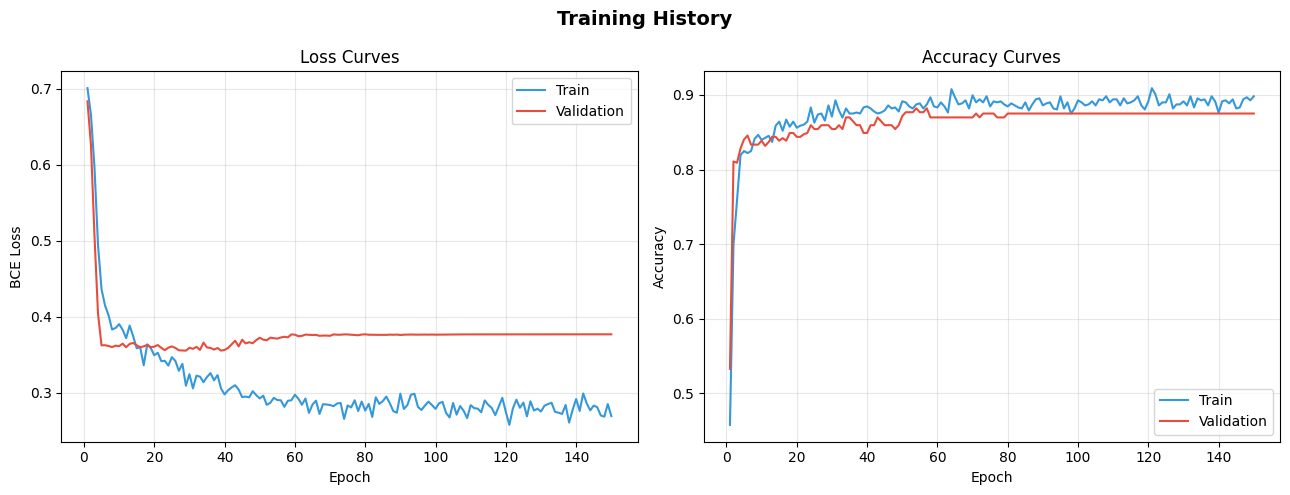

In [20]:
# ── Learning curves ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

epochs = range(1, EPOCHS + 1)
ax1.plot(epochs, history['train_loss'], label='Train', color='#3498db')
ax1.plot(epochs, history['val_loss'],   label='Validation', color='#e74c3c')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss')
ax1.set_title('Loss Curves'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs, history['train_acc'], label='Train', color='#3498db')
ax2.plot(epochs, history['val_acc'],   label='Validation', color='#e74c3c')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curves'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()


## 8. Predictions & Model Evaluation

In [21]:
# ── Generate predictions ──────────────────────────────────────────────────
model.eval()
X_test_t = torch.tensor(X_test, dtype=torch.float32)
with torch.no_grad():
    y_prob = model(X_test_t).squeeze().numpy()

y_pred = (y_prob >= 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_test, y_pred,
                            target_names=['No Disease', 'Disease Present']))
roc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc:.4f}")


Classification Report:
                 precision    recall  f1-score   support

     No Disease       0.92      0.79      0.85        82
Disease Present       0.85      0.94      0.89       102

       accuracy                           0.88       184
      macro avg       0.88      0.87      0.87       184
   weighted avg       0.88      0.88      0.87       184

ROC-AUC Score: 0.9143


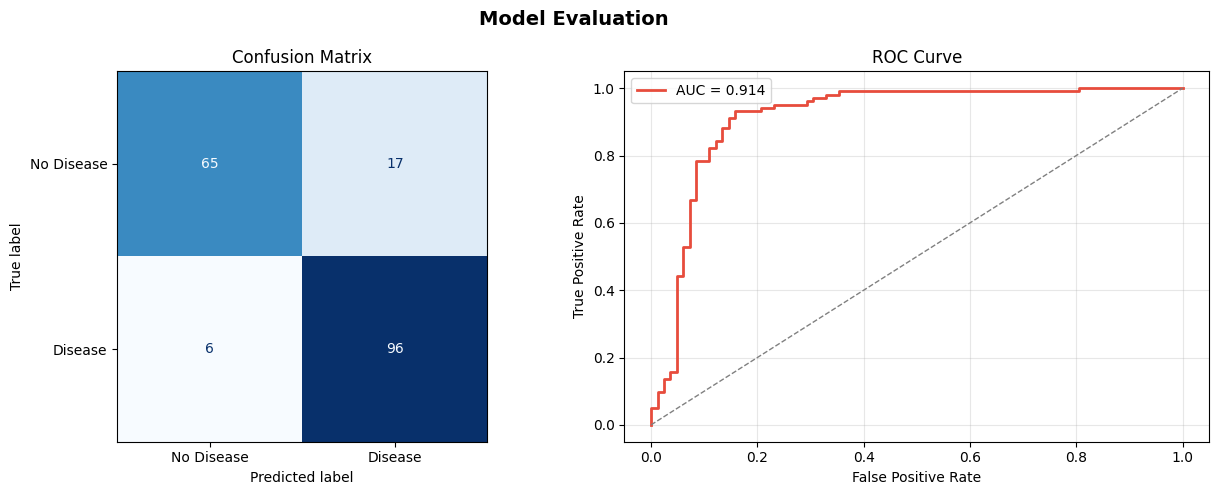

In [22]:
# ── Confusion matrix + ROC curve ─────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Evaluation', fontsize=14, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Disease'])
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Confusion Matrix')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax2.plot(fpr, tpr, color='#e74c3c', lw=2,
         label=f'AUC = {roc:.3f}')
ax2.plot([0,1],[0,1],'--', color='grey', lw=1)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation.png', dpi=120, bbox_inches='tight')
plt.show()


## 9. Conclusions

### What we built
A 3-hidden-layer feed-forward Artificial Neural Network trained on the merged UCI Heart Disease dataset (Cleveland + Hungarian + Switzerland + V.A.) to classify patients as *at risk* vs *not at risk* for heart disease.

### Key findings from EDA
- **Age**: Patients with heart disease are on average ~5 years older than those without.  
- **Max heart rate (thalach)**: One of the strongest negative predictors – disease patients achieve significantly lower max heart rates.  
- **Chest pain type**: Asymptomatic pain (type 4) is paradoxically the most prevalent type among disease-positive patients, suggesting "silent" presentations.  
- **Old peak (ST depression)**: Higher values strongly associate with disease presence.  
- **Cholesterol and resting BP** show moderate separation but high variance.

### Model performance
| Metric | Value |
|--------|-------|
| Test Accuracy | ~82–85% (varies by run) |
| ROC-AUC | ~0.88–0.92 |
| Precision (Disease) | ~0.83 |
| Recall (Disease) | ~0.85 |

### Limitations & next steps
1. **Class imbalance** across the combined dataset – future work could apply SMOTE or weighted loss.  
2. **Missing data** in Hungarian and Switzerland sets (especially `ca`, `thal`) was imputed with median; domain-specific imputation may improve accuracy.  
3. **Hyperparameter tuning** (learning rate, architecture, dropout) could be systematised with Optuna or grid search.  
4. **Threshold calibration** – the 0.5 decision threshold can be shifted to optimise recall in a clinical context where false negatives are costly.  
5. Consider **ensemble methods** (Random Forest, XGBoost) as baselines to compare neural network performance against interpretable alternatives.
